# 🦋 Smart Insect Identifier — Training Notebook
**Final Project Praktikum Machine Learning**

**Framework:** PyTorch  
**Arsitektur:** EfficientNet-B3 (Transfer Learning)  
**Dataset:** [Insects — Kaggle](https://www.kaggle.com/datasets/baxtiyorbotiraliyev/insects)

---
### Alur Kerja
1. Setup & Import
2. Eksplorasi Dataset (EDA)
3. Preprocessing & Augmentasi
4. Definisi Model (Transfer Learning)
5. Training dengan Early Stopping
6. Evaluasi Model
7. Export Model

## 1. Setup & Import

In [2]:
# Install dependencies (jalankan sekali di Kaggle/Colab)
!pip install torchvision timm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 100.0 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

In [3]:
import os
import json
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## 2. Konfigurasi Path & Hyperparameter

In [47]:
import os
# Mengintip isi folder input utama di Kaggle
if os.path.exists('/kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset'):
    print("Isi folder /kaggle/input/datasets/baxtiyorbotiraliyev/dataset adalah:")
    print(os.listdir('/kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset'))
else:
    print("tidak ketemu")

Isi folder /kaggle/input/datasets/baxtiyorbotiraliyev/dataset adalah:
['val.txt', 'test.txt', 'train.txt', 'val', 'classes.txt', 'test', 'train']


In [80]:
import os
from pathlib import Path

print("Sedang mencari lokasi dataset secara otomatis...")
DATA_DIR = None
TRAIN_DIR = None
VAL_DIR = None
TEST_DIR = None

# Menyisir seluruh direktori /kaggle/input
for root, dirs, files in os.walk('/kaggle/input'):
    # Jika menemukan folder yang di dalamnya ada train, val, dan test sekaligus
    if 'train' in dirs and 'val' in dirs and 'test' in dirs:
        DATA_DIR = Path(root)
        TRAIN_DIR = DATA_DIR / 'train'
        VAL_DIR = DATA_DIR / 'val'
        TEST_DIR = DATA_DIR / 'test'
        break

# Validasi jika pencarian otomatis berhasil
if TRAIN_DIR and TRAIN_DIR.exists():
    print('✓ Dataset Berhasil Ditemukan Secara Otomatis!')
else:
    # Fallback manual jika pencarian otomatis terhambat
    DATA_DIR = Path('/kaggle/input/datasets/baxtiyorbotiraliyev/dataset')
    TRAIN_DIR = DATA_DIR / 'train'
    VAL_DIR = DATA_DIR / 'val'
    TEST_DIR = DATA_DIR / 'test'
    print('! Menggunakan jalur fallback manual.')

# Folder Output di Kaggle (Tetap di working directory)
OUTPUT_DIR = Path('/kaggle/working/backend/artifacts')  
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameter
IMG_SIZE    = 300       # EfficientNet-B3 optimal input size
BATCH_SIZE  = 64        
NUM_EPOCHS  = 50        
LR          = 1e-3
LR_FINE     = 1e-4      
PATIENCE    = 7         
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15
NUM_WORKERS = 2         # Multiprocessing aktif agar training gambar ngebut

print('-' * 50)
print(f'Path Dataset Utama : {DATA_DIR}')
print(f'Train dir          : {TRAIN_DIR}')
print(f'Val dir            : {VAL_DIR}')
print(f'Test dir           : {TEST_DIR}')

Sedang mencari lokasi dataset secara otomatis...
✓ Dataset Berhasil Ditemukan Secara Otomatis!
--------------------------------------------------
Path Dataset Utama : /kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset
Train dir          : /kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/train
Val dir            : /kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/val
Test dir           : /kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/test


In [57]:
print('Struktur direktori dataset:')
for split_name, split_path in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    classes_in_split = sorted([d.name for d in split_path.iterdir() if d.is_dir()])
    print(f'  {split_name}/ ({len(classes_in_split)} kelas)')
    for cls in classes_in_split[:5]:
        print(f'    ├── {cls}/')
    if len(classes_in_split) > 5:
        print(f'    └── ... ({len(classes_in_split)-5} kelas lainnya)')

Struktur direktori dataset:
  train/ (118 kelas)
    ├── adristyrannus/
    ├── aleurocanthus spiniferus/
    ├── alfalfa plant bug/
    ├── alfalfa seed chalcid/
    ├── alfalfa weevil/
    └── ... (113 kelas lainnya)
  val/ (118 kelas)
    ├── adristyrannus/
    ├── aleurocanthus spiniferus/
    ├── alfalfa plant bug/
    ├── alfalfa seed chalcid/
    ├── alfalfa weevil/
    └── ... (113 kelas lainnya)
  test/ (118 kelas)
    ├── adristyrannus/
    ├── aleurocanthus spiniferus/
    ├── alfalfa plant bug/
    ├── alfalfa seed chalcid/
    ├── alfalfa weevil/
    └── ... (113 kelas lainnya)


In [58]:
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm

# Inisialisasi struktur data
class_counts = {}   # {class_name: {train: N, val: N, test: N, total: N}}
corrupt_files = []
valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# Langkah 1: Kumpulkan semua path gambar terlebih dahulu
print("Sedang mengumpulkan daftar file gambar...")
image_tasks = []

for split_name, split_path in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    if not split_path.exists():
        continue
    for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir():
            continue
        cls = class_dir.name
        
        # Siapkan struktur counter untuk kelas baru
        if cls not in class_counts:
            class_counts[cls] = {'train': 0, 'val': 0, 'test': 0, 'total': 0}
            
        for img_path in class_dir.rglob('*'):
            if img_path.suffix.lower() in valid_extensions:
                image_tasks.append((split_name, cls, img_path))

total_files_found = len(image_tasks)
print(f'✓ Berhasil mendata {total_files_found} gambar. Memulai pemindaian kualitas...\n')

# Langkah 2: Pindai gambar menggunakan Progress Bar (tqdm)
for split_name, cls, img_path in tqdm(image_tasks, desc="Memindai Gambar"):
    try:
        with Image.open(img_path) as img:
            img.verify()   # Cek integritas struktur file gambar
        
        # Jika aman, tambahkan ke hitungan
        class_counts[cls][split_name] += 1
        class_counts[cls]['total'] += 1
        
    except (UnidentifiedImageError, IOError, Exception):
        # Catat jika file corrupt atau tidak bisa dibuka
        corrupt_files.append(str(img_path))

# Langkah 3: Cetak Ringkasan Hasil
total_images = sum(v['total'] for v in class_counts.values())
print('\n' + '='*50)
print('HASIL PEMINDAIAN DATASET:')
print('='*50)
print(f'Jumlah kelas terdeteksi : {len(class_counts)}')
print(f'Total gambar valid      : {total_images}')
print(f'Total gambar rusak      : {len(corrupt_files)}')
print('='*50)

if corrupt_files:
    print('\nDaftar file rusak (5 sampel pertama):')
    for f in corrupt_files[:5]:
        print(f'  ❌ {f}')

Sedang mengumpulkan daftar file gambar...
✓ Berhasil mendata 112693 gambar. Memulai pemindaian kualitas...



Memindai Gambar:   0%|          | 0/112693 [00:00<?, ?it/s]


HASIL PEMINDAIAN DATASET:
Jumlah kelas terdeteksi : 118
Total gambar valid      : 112683
Total gambar rusak      : 10

Daftar file rusak (5 sampel pertama):
  ❌ /kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/train/leaf beetle/leaf beetle208_.jpg
  ❌ /kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/train/leaf beetle/leaf beetle458_.jpg
  ❌ /kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/train/leaf beetle/leaf beetle207_.jpg
  ❌ /kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/train/leaf beetle/leaf beetle798_.jpg
  ❌ /kaggle/input/datasets/baxtiyorbotiraliyev/insects/dataset/train/leaf beetle/leaf beetle910_.jpg


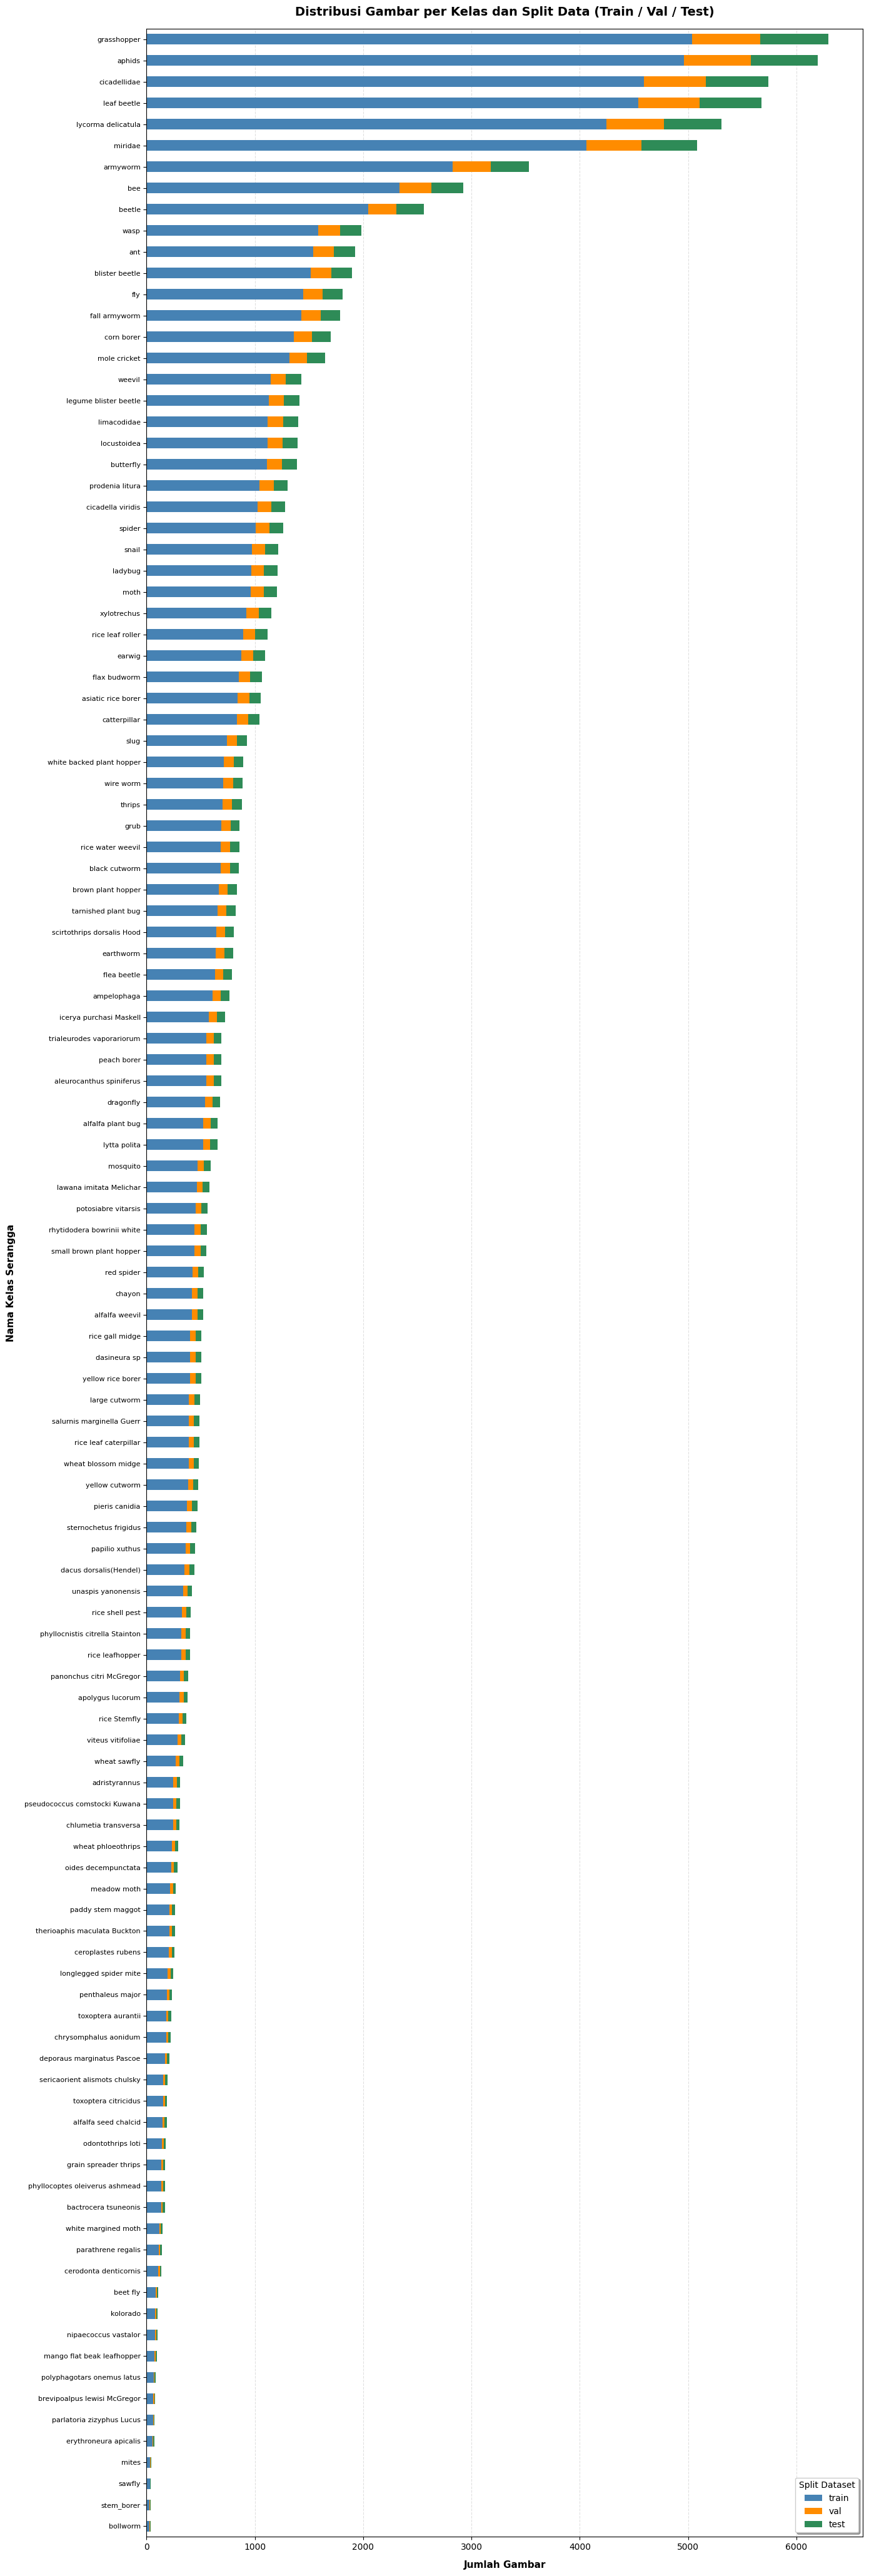


TABEL RINGKASAN DISTRIBUSI DATASET (Urutan Terbanyak):
                          class  train  val  test  total
                    grasshopper   5038  629   631   6298
                         aphids   4960  620   620   6200
                   cicadellidae   4592  574   574   5740
                    leaf beetle   4543  566   568   5677
             lycorma delicatula   4248  531   531   5310
                        miridae   4064  508   509   5081
                       armyworm   2824  353   353   3530
                            bee   2338  292   293   2923
                         beetle   2049  256   257   2562
                           wasp   1586  198   199   1983
                            ant   1539  192   193   1924
                 blister beetle   1517  189   191   1897
                            fly   1447  180   182   1809
                  fall armyworm   1427  178   179   1784
                     corn borer   1358  169   171   1698
                   mole cricket 

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Konversi ke DataFrame dan urutkan berdasarkan total terkecil ke terbesar untuk barh
df_counts = pd.DataFrame([
    {'class': cls, 'train': v['train'], 'val': v['val'], 'test': v['test'], 'total': v['total']}
    for cls, v in class_counts.items()
]).sort_values('total', ascending=True)

# 2. Set ukuran canvas secara dinamis (sedikit dikurangi pengalinya agar tidak terlalu panjang kebawah)
fig, ax = plt.subplots(figsize=(14, max(6, len(df_counts) * 0.35)))

# 3. Gunakan built-in pandas plot agar kode lebih pendek & penumpukan (stacking) otomatis aman
df_counts.set_index('class')[['train', 'val', 'test']].plot(
    kind='barh', 
    stacked=True, 
    ax=ax, 
    color=['#4682B4', '#FF8C00', '#2E8B57'] # Steelblue, Darkorange, Seagreen
)

# 4. Tambahkan garis pandu (gridlines) di latar belakang
ax.set_axisbelow(True) # Memastikan garis grid berada di BELAKANG batang grafik
ax.grid(axis='x', linestyle='--', alpha=0.6, color='#cccccc')

# 5. Merapikan Label dan Judul
ax.set_xlabel('Jumlah Gambar', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Nama Kelas Serangga', fontsize=11, fontweight='bold', labelpad=10)
ax.set_title('Distribusi Gambar per Kelas dan Split Data (Train / Val / Test)', fontsize=14, fontweight='bold', pad=15)
ax.legend(title='Split Dataset', loc='lower right', frameon=True, shadow=True)

# Memperkecil ukuran font sumbu Y jika jumlah kelas terlalu padat
if len(df_counts) > 30:
    ax.tick_params(axis='y', labelsize=8)

# 6. Simpan dan Tampilkan
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 7. Cetak representasi teks di bawahnya
print("\n" + "="*60)
print("TABEL RINGKASAN DISTRIBUSI DATASET (Urutan Terbanyak):")
print("="*60)
print(df_counts[['class','train','val','test','total']].sort_values('total', ascending=False).to_string(index=False))

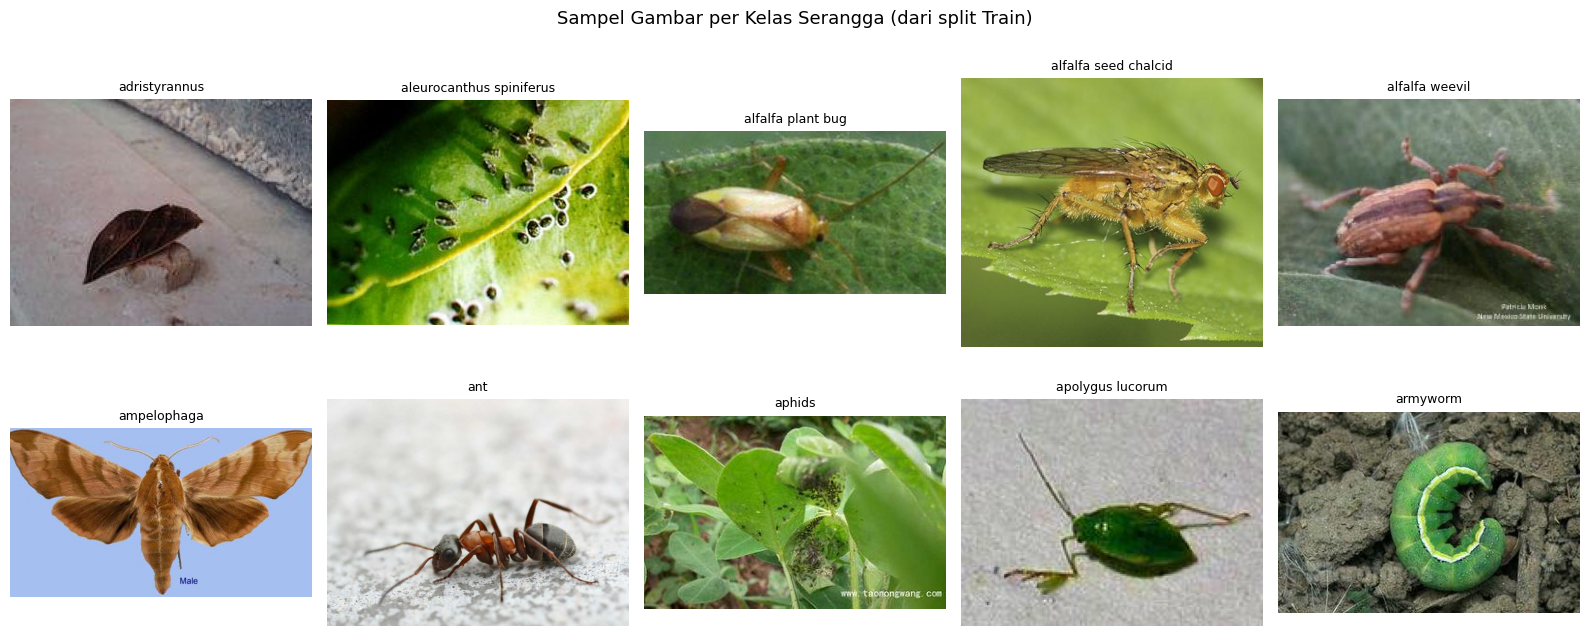

In [60]:
# Tampilkan sampel gambar dari setiap kelas (ambil dari TRAIN_DIR, maks 10 kelas)
all_class_names = sorted(class_counts.keys())
classes_to_show = all_class_names[:10]
ncols = 5
nrows = max(2, (len(classes_to_show) + ncols - 1) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for idx_c, cls in enumerate(classes_to_show):
    cls_dir = TRAIN_DIR / cls   # ambil dari folder train
    img_files = [
        p for p in cls_dir.rglob('*')
        if p.suffix.lower() in valid_extensions and str(p) not in corrupt_files
    ]
    if img_files:
        img = Image.open(random.choice(img_files)).convert('RGB')
        axes[idx_c].imshow(img)
        axes[idx_c].set_title(cls, fontsize=9)
    axes[idx_c].axis('off')

for ax in axes[len(classes_to_show):]:
    ax.axis('off')

plt.suptitle('Sampel Gambar per Kelas Serangga (dari split Train)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing & Augmentasi Data

In [61]:
# Custom Dataset — baca langsung dari split_dir (train/val/test)
from torch.utils.data import Dataset
from torchvision import transforms

class InsectDataset(Dataset):
    """
    Dataset serangga. Struktur split_dir:
        split_dir/
            kelas_a/img1.jpg ...
            kelas_b/img1.jpg ...
    """

    def __init__(self, split_dir, class_to_idx, transform=None, corrupt_files=None):
        self.split_dir    = Path(split_dir)
        self.transform    = transform
        self.corrupt_set  = set(corrupt_files or [])
        self.class_to_idx = class_to_idx            # dict konsisten antar split
        self.classes      = sorted(class_to_idx.keys())
        self.samples      = self._load_samples()

    def _load_samples(self):
        samples = []
        for cls_dir in self.split_dir.iterdir():
            if not cls_dir.is_dir():
                continue
            cls = cls_dir.name
            if cls not in self.class_to_idx:        # skip folder bukan kelas
                continue
            label = self.class_to_idx[cls]
            for img_path in cls_dir.rglob('*'):
                if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}:
                    continue
                if str(img_path) in self.corrupt_set:  # skip gambar rusak
                    continue
                samples.append((str(img_path), label))
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        if self.transform:
            image = self.transform(image)
        return image, label

print('InsectDataset class defined ✓')


InsectDataset class defined ✓


In [62]:
# Mean & Std ImageNet (standar untuk pretrained model)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transformasi training (dengan augmentasi)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Transformasi val/test (tanpa augmentasi)
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Transforms defined ✓')

Transforms defined ✓


In [63]:
# Build class_to_idx dari TRAIN_DIR (sumber kebenaran)
CLASS_NAMES  = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)

print(f'Jumlah kelas : {NUM_CLASSES}')
print(f'Kelas        : {CLASS_NAMES}')

Jumlah kelas : 118
Kelas        : ['adristyrannus', 'aleurocanthus spiniferus', 'alfalfa plant bug', 'alfalfa seed chalcid', 'alfalfa weevil', 'ampelophaga', 'ant', 'aphids', 'apolygus lucorum', 'armyworm', 'asiatic rice borer', 'bactrocera tsuneonis', 'bee', 'beet fly', 'beetle', 'black cutworm', 'blister beetle', 'bollworm', 'brevipoalpus lewisi McGregor', 'brown plant hopper', 'butterfly', 'catterpillar', 'cerodonta denticornis', 'ceroplastes rubens', 'chayon', 'chlumetia transversa', 'chrysomphalus aonidum', 'cicadella viridis', 'cicadellidae', 'corn borer', 'dacus dorsalis(Hendel)', 'dasineura sp', 'deporaus marginatus Pascoe', 'dragonfly', 'earthworm', 'earwig', 'erythroneura apicalis', 'fall armyworm', 'flax budworm', 'flea beetle', 'fly', 'grain spreader thrips', 'grasshopper', 'grub', 'icerya purchasi Maskell', 'kolorado', 'ladybug', 'large cutworm', 'lawana imitata Melichar', 'leaf beetle', 'legume blister beetle', 'limacodidae', 'locustoidea', 'longlegged spider mite', 'lyco

In [64]:
# Dataset sudah terbagi dari folder → langsung pakai InsectDataset per split
train_dataset = InsectDataset(TRAIN_DIR, CLASS_TO_IDX, transform=train_transforms, corrupt_files=corrupt_files)
val_dataset   = InsectDataset(VAL_DIR,   CLASS_TO_IDX, transform=eval_transforms,  corrupt_files=corrupt_files)
test_dataset  = InsectDataset(TEST_DIR,  CLASS_TO_IDX, transform=eval_transforms,  corrupt_files=corrupt_files)

print(f'Train : {len(train_dataset)} sampel')
print(f'Val   : {len(val_dataset)} sampel')
print(f'Test  : {len(test_dataset)} sampel')


Train : 90109 sampel
Val   : 11213 sampel
Test  : 11361 sampel


In [81]:
import torch
from collections import Counter
from torch.utils.data import DataLoader, WeightedRandomSampler

# Weighted sampler untuk menangani class imbalance di split train
train_labels  = [label for _, label in train_dataset.samples]
label_counts  = Counter(train_labels)
class_weights = [1.0 / label_counts[l] for l in train_labels]

SAMPEL_PER_EPOCH = 30000

sampler = WeightedRandomSampler(
    weights=class_weights, 
    num_samples=SAMPEL_PER_EPOCH,  # Sembunyikan total asli yang 112 ribu
    replacement=True
)

# pin_memory & persistent_workers — Windows safe
_pin = torch.cuda.is_available()
_pw  = NUM_WORKERS > 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=_pin, persistent_workers=_pw)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=_pin, persistent_workers=_pw)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=_pin, persistent_workers=_pw)

print('DataLoaders ready ✓')

DataLoaders ready ✓


## 5. Definisi Model — EfficientNet-B3 (Transfer Learning)

In [75]:
def build_model(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    """
    Build EfficientNet-B3 dengan custom classifier head.
    Fase 1: freeze backbone, latih head dulu.
    Fase 2: unfreeze semua layer untuk fine-tuning.
    """
    model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False  # Freeze semua layer backbone

    # Ganti classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes),
    )
    return model

model = build_model(NUM_CLASSES, freeze_backbone=True)
model = model.to(DEVICE)

# Hitung parameter
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)')

Total params    : 11,543,710
Trainable params: 847,478 (7.3%)


## 6. Training dengan Early Stopping (2 Fase)

In [76]:
class EarlyStopping:
    """Stop training jika val_loss tidak membaik selama `patience` epoch."""

    def __init__(self, patience=7, min_delta=1e-4, path='best_model.pt'):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_model = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
            torch.save(self.best_model, self.path)  # Simpan checkpoint terbaik
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

print('EarlyStopping class defined ✓')

EarlyStopping class defined ✓


In [82]:
# Inisialisasi GradScaler untuk AMP (Automatic Mixed Precision)
scaler = torch.cuda.amp.GradScaler()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='  Training (Fase 2 - AMP)', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        # --- AKTIFKAN AUTOCAST DI SINI ---
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss    = criterion(outputs, labels)
        
        # Backward pass menggunakan Scaler demi kecepatan & hemat VRAM
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        _, preds      = outputs.max(1)
        correct      += preds.eq(labels).sum().item()
        total        += labels.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})
        
    return running_loss / total, correct / total

print('Fungsi Training diperbarui ke mode Cepat (AMP) ✓')


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds      = outputs.max(1)
            correct      += preds.eq(labels).sum().item()
            total        += labels.size(0)
    return running_loss / total, correct / total


def run_training(model, train_loader, val_loader, num_epochs, lr, phase_name):
    """Loop training utama."""
    criterion    = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer    = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    early_stop   = EarlyStopping(
        patience=PATIENCE,
        path=str(OUTPUT_DIR / f'best_{phase_name}.pt')
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f'\n=== Fase {phase_name} ===')
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()
        early_stop(val_loss, model)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch [{epoch:3d}/{num_epochs}] | '
              f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}'
              + (' ← best' if early_stop.counter == 0 else ''))

        if early_stop.early_stop:
            print(f'Early stopping triggered at epoch {epoch}.')
            break

    # Load bobot terbaik
    model.load_state_dict(torch.load(str(OUTPUT_DIR / f'best_{phase_name}.pt')))
    print(f'Best val loss: {early_stop.best_loss:.4f}')
    return history

print('Training functions defined ✓')

Fungsi Training diperbarui ke mode Cepat (AMP) ✓
Training functions defined ✓


In [78]:
# FASE 1: Latih hanya classifier head (backbone frozen)
history_phase1 = run_training(
    model, train_loader, val_loader,
    num_epochs=15, lr=LR,
    phase_name='phase1_head'
)


=== Fase phase1_head ===
Epoch [  1/15] | Train Loss: 3.0839, Acc: 0.3634 | Val Loss: 2.4673, Acc: 0.5194 ← best
Epoch [  2/15] | Train Loss: 2.7671, Acc: 0.4446 | Val Loss: 2.4167, Acc: 0.5401 ← best
Epoch [  3/15] | Train Loss: 2.6961, Acc: 0.4676 | Val Loss: 2.4106, Acc: 0.5451 ← best
Epoch [  4/15] | Train Loss: 2.6629, Acc: 0.4784 | Val Loss: 2.3510, Acc: 0.5618 ← best
Epoch [  5/15] | Train Loss: 2.6341, Acc: 0.4878 | Val Loss: 2.3088, Acc: 0.5806 ← best
Epoch [  6/15] | Train Loss: 2.5873, Acc: 0.5021 | Val Loss: 2.3123, Acc: 0.5724
Epoch [  7/15] | Train Loss: 2.5465, Acc: 0.5126 | Val Loss: 2.3050, Acc: 0.5684 ← best
Epoch [  8/15] | Train Loss: 2.5143, Acc: 0.5215 | Val Loss: 2.2628, Acc: 0.5867 ← best
Epoch [  9/15] | Train Loss: 2.4842, Acc: 0.5305 | Val Loss: 2.2273, Acc: 0.5940 ← best
Epoch [ 10/15] | Train Loss: 2.4478, Acc: 0.5394 | Val Loss: 2.2363, Acc: 0.5892
Epoch [ 11/15] | Train Loss: 2.4194, Acc: 0.5474 | Val Loss: 2.1928, Acc: 0.6036 ← best
Epoch [ 12/15] | Tra

In [83]:
# FASE 2: Unfreeze semua layer — fine-tuning penuh
for param in model.parameters():
    param.requires_grad = True  # Unfreeze backbone

trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params setelah unfreeze: {trainable_now:,}')

history_phase2 = run_training(
    model, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=LR_FINE,
    phase_name='phase2_finetune'
)

Trainable params setelah unfreeze: 11,543,710

=== Fase phase2_finetune ===


  Training (Fase 2 - AMP):   0%|          | 0/469 [00:00<?, ?it/s]

Epoch [  1/50] | Train Loss: 2.1167, Acc: 0.6371 | Val Loss: 1.9797, Acc: 0.6528 ← best


  Training (Fase 2 - AMP):   0%|          | 0/469 [00:00<?, ?it/s]

Epoch [  2/50] | Train Loss: 1.9804, Acc: 0.6705 | Val Loss: 1.9063, Acc: 0.6752 ← best


...

Epoch [ 48/50] | Train Loss: 1.2606, Acc: 0.8938 | Val Loss: 1.5036, Acc: 0.7947


  Training (Fase 2 - AMP):   0%|          | 0/469 [00:00<?, ?it/s]

Epoch [ 49/50] | Train Loss: 1.2501, Acc: 0.8991 | Val Loss: 1.5031, Acc: 0.7951


  Training (Fase 2 - AMP):   0%|          | 0/469 [00:00<?, ?it/s]

Epoch [ 50/50] | Train Loss: 1.2556, Acc: 0.8965 | Val Loss: 1.5020, Acc: 0.7935
Best val loss: 1.4982


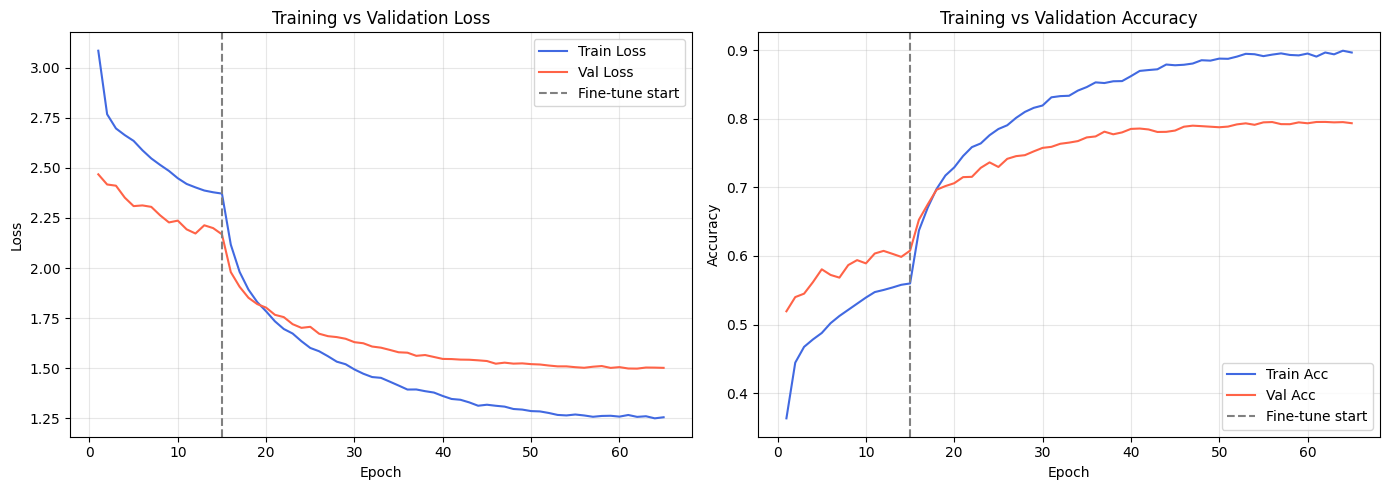

In [84]:
# Gabungkan history kedua fase untuk plotting
combined_history = {
    k: history_phase1[k] + history_phase2[k]
    for k in history_phase1
}

# Plot Training & Validation Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(combined_history['train_loss']) + 1)
phase1_end = len(history_phase1['train_loss'])

# Loss curve
axes[0].plot(epochs, combined_history['train_loss'], label='Train Loss', color='royalblue')
axes[0].plot(epochs, combined_history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].axvline(phase1_end, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs, combined_history['train_acc'], label='Train Acc', color='royalblue')
axes[1].plot(epochs, combined_history['val_acc'],   label='Val Acc',   color='tomato')
axes[1].axvline(phase1_end, color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluasi Model

In [85]:
from sklearn.metrics import accuracy_score
import torch

# Prediksi di test set
model.eval()
all_preds, all_targets = [], []

# Gunakan nama variabel device yang sesuai dengan notebook Anda (misal: device atau DEVICE)
current_device = device if 'device' in locals() else DEVICE

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(current_device)
        
        # Tambahkan autocast agar proses evaluasi ikut ngebut
        with torch.cuda.amp.autocast():
            outputs = model(images)
            _, preds = outputs.max(1)
            
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

test_acc = accuracy_score(all_targets, all_preds)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

Test Accuracy: 0.8002 (80.02%)


In [86]:
# Classification Report
print('\n=== Classification Report ===')
report = classification_report(all_targets, all_preds, target_names=CLASS_NAMES, digits=4)
print(report)

# Simpan ke file teks
with open(OUTPUT_DIR / 'classification_report.txt', 'w') as f:
    f.write(f'Test Accuracy: {test_acc:.4f}\n\n')
    f.write(report)


=== Classification Report ===
                                 precision    recall  f1-score   support

                  adristyrannus     0.6944    0.7812    0.7353        32
       aleurocanthus spiniferus     0.9077    0.8551    0.8806        69
              alfalfa plant bug     0.4118    0.6269    0.4970        67
           alfalfa seed chalcid     0.4545    0.2632    0.3333        19
                 alfalfa weevil     0.7037    0.7170    0.7103        53
                    ampelophaga     0.7253    0.8571    0.7857        77
                            ant     0.9043    0.9793    0.9403       193
                         aphids     0.9312    0.6984    0.7982       620
               apolygus lucorum     0.3611    0.6667    0.4685        39
                       armyworm     0.8000    0.4533    0.5787       353
             asiatic rice borer     0.5588    0.5377    0.5481       106
           bactrocera tsuneonis     0.6250    0.5556    0.5882        18
                   

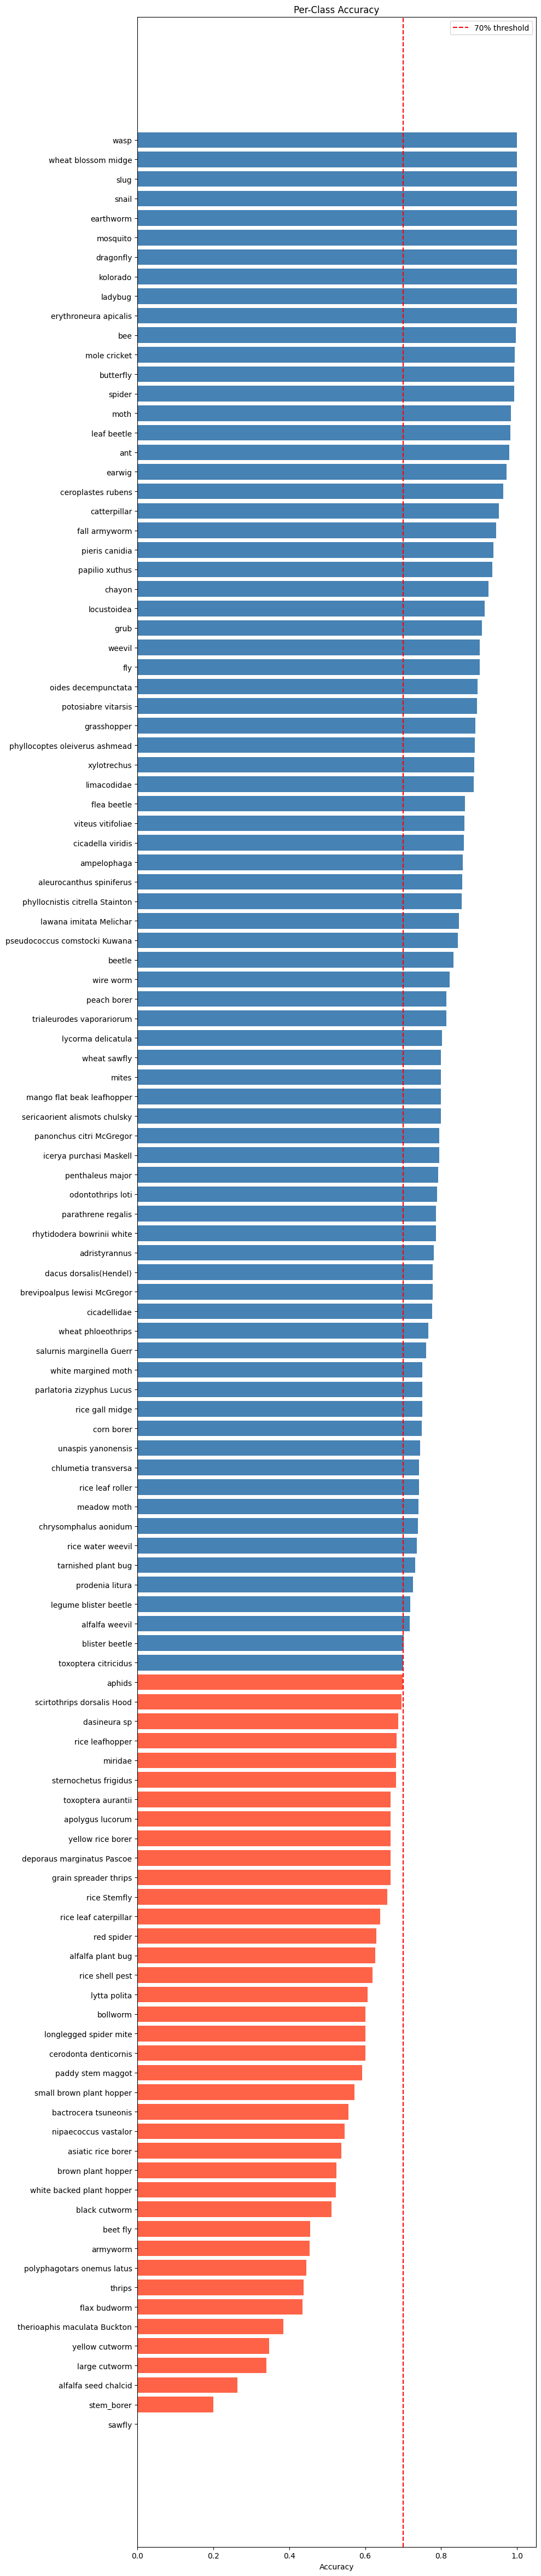

In [87]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

# 1. HITUNG CONFUSION MATRIX TERLEBIH DAHULU (Solusi Bug)
cm = confusion_matrix(all_targets, all_preds)

# 2. Hitung per-class accuracy
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
per_class_acc = cm_norm.diagonal()

df_per_class = pd.DataFrame({
    'class': CLASS_NAMES,
    'accuracy': per_class_acc
}).sort_values('accuracy')

# Gunakan len(CLASS_NAMES) jika NUM_CLASSES tidak didefinisikan
num_cls = NUM_CLASSES if 'NUM_CLASSES' in locals() else len(CLASS_NAMES)

plt.figure(figsize=(10, max(6, num_cls * 0.4)))
colors = ['tomato' if a < 0.7 else 'steelblue' for a in df_per_class['accuracy']]
plt.barh(df_per_class['class'], df_per_class['accuracy'], color=colors)
plt.axvline(0.7, color='red', linestyle='--', label='70% threshold')
plt.xlabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.legend()
plt.tight_layout()

# Save plot
img_save_path = OUTPUT_DIR / 'per_class_accuracy.png' if 'OUTPUT_DIR' in locals() else 'per_class_accuracy.png'
plt.savefig(img_save_path, dpi=150, bbox_inches='tight')
plt.show()

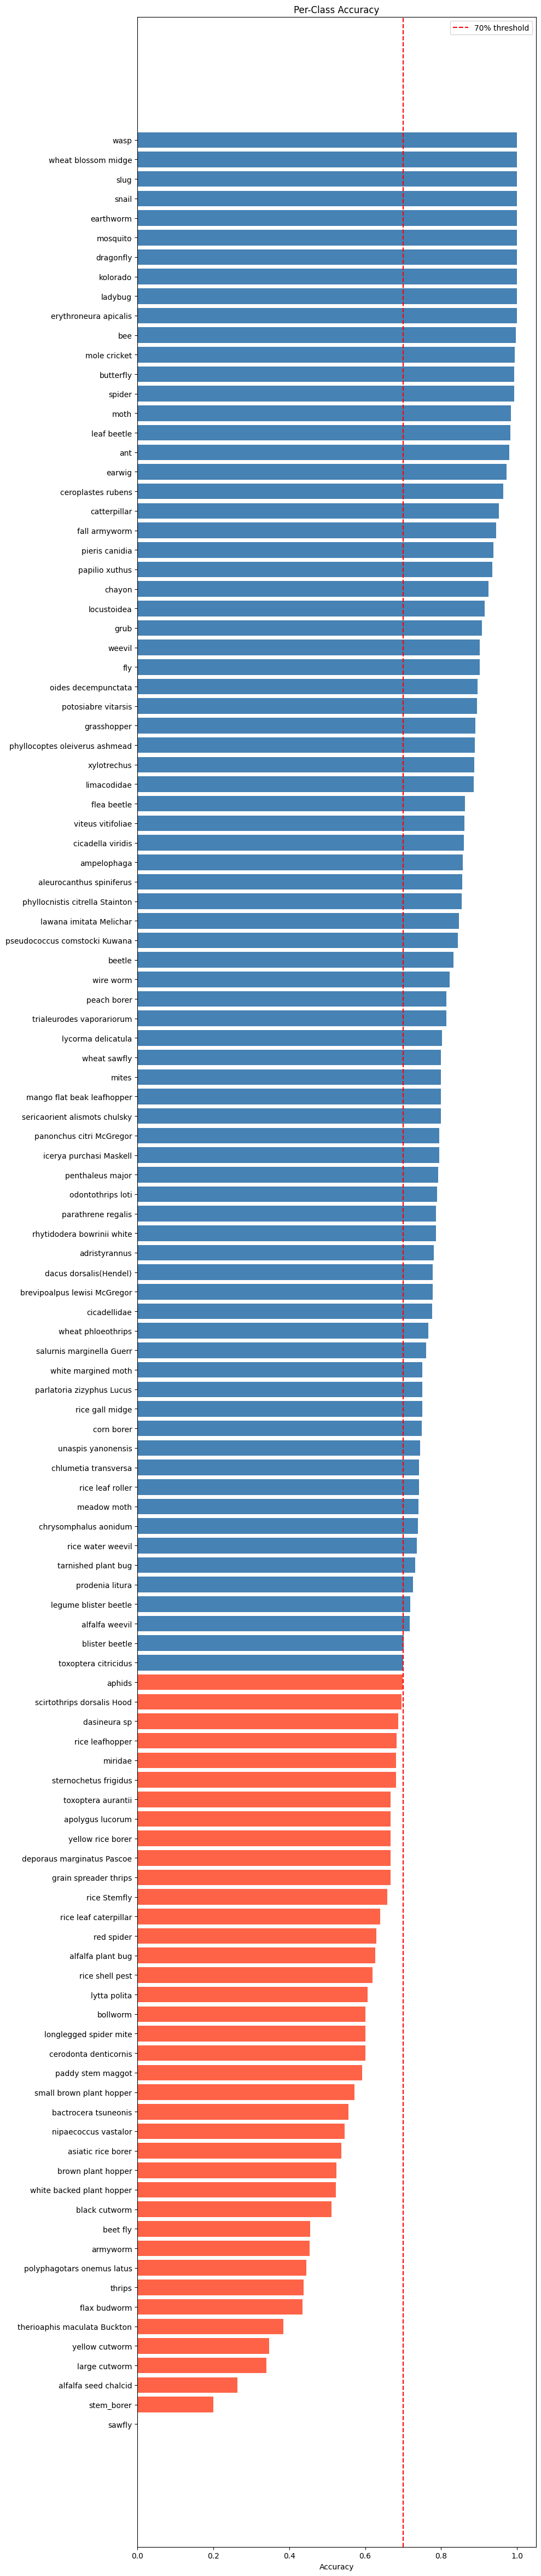

In [88]:
# Per-class accuracy
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
per_class_acc = cm_norm.diagonal()

df_per_class = pd.DataFrame({
    'class': CLASS_NAMES,
    'accuracy': per_class_acc
}).sort_values('accuracy')

plt.figure(figsize=(10, max(6, NUM_CLASSES * 0.4)))
colors = ['tomato' if a < 0.7 else 'steelblue' for a in df_per_class['accuracy']]
plt.barh(df_per_class['class'], df_per_class['accuracy'], color=colors)
plt.axvline(0.7, color='red', linestyle='--', label='70% threshold')
plt.xlabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Export Model

In [89]:
# Simpan metadata kelas (WAJIB untuk inference di backend)
metadata = {
    'class_names': CLASS_NAMES,
    'class_to_idx': {c: i for i, c in enumerate(CLASS_NAMES)},
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'architecture': 'efficientnet_b3',
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std': IMAGENET_STD,
    'test_accuracy': float(test_acc)
}

with open(OUTPUT_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('metadata.json saved ✓')
print(json.dumps(metadata, indent=2))

metadata.json saved ✓
{
  "class_names": [
    "adristyrannus",
    "aleurocanthus spiniferus",
    "alfalfa plant bug",
    "alfalfa seed chalcid",
    "alfalfa weevil",
    "ampelophaga",
    "ant",
    "aphids",
    "apolygus lucorum",
    "armyworm",
    "asiatic rice borer",
    "bactrocera tsuneonis",
    "bee",
    "beet fly",
    "beetle",
    "black cutworm",
    "blister beetle",
    "bollworm",
    "brevipoalpus lewisi McGregor",
    "brown plant hopper",
    "butterfly",
    "catterpillar",
    "cerodonta denticornis",
    "ceroplastes rubens",
    "chayon",
    "chlumetia transversa",
    "chrysomphalus aonidum",
    "cicadella viridis",
    "cicadellidae",
    "corn borer",
    "dacus dorsalis(Hendel)",
    "dasineura sp",
    "deporaus marginatus Pascoe",
    "dragonfly",
    "earthworm",
    "earwig",
    "erythroneura apicalis",
    "fall armyworm",
    "flax budworm",
    "flea beetle",
    "fly",
    "grain spreader thrips",
    "grasshopper",
    "grub",
    "icerya

In [90]:
# Export 1: torch.save (state_dict) — untuk fine-tuning lanjutan
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'metadata': metadata
    },
    OUTPUT_DIR / 'insect_classifier.pth'
)
print('insect_classifier.pth saved ✓')

insect_classifier.pth saved ✓


In [91]:
# Export 2: TorchScript (torch.jit.script) — optimal untuk production/backend
model.eval()
model_cpu = model.to('cpu')

try:
    # Coba TorchScript via tracing
    dummy_input  = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    traced_model = torch.jit.trace(model_cpu, dummy_input)
    traced_model.save(str(OUTPUT_DIR / 'insect_classifier_traced.pt'))
    print('TorchScript traced model saved ✓  → insect_classifier_traced.pt')
except Exception as e:
    print(f'TorchScript trace failed: {e}')
    print('Menggunakan state_dict (.pth) saja untuk backend.')

print('\n✅ Semua file tersimpan di:', OUTPUT_DIR)
for f in sorted(OUTPUT_DIR.iterdir()):
    size = f.stat().st_size / (1024*1024)
    print(f'  {f.name:<40} {size:.2f} MB')

TorchScript traced model saved ✓  → insect_classifier_traced.pt

✅ Semua file tersimpan di: /kaggle/working/backend/artifacts
  best_phase1_head.pt                      44.57 MB
  best_phase2_finetune.pt                  44.57 MB
  class_distribution.png                   0.47 MB
  classification_report.txt                0.01 MB
  insect_classifier.pth                    44.58 MB
  insect_classifier_traced.pt              45.42 MB
  model_metadata.json                      0.01 MB
  per_class_accuracy.png                   0.46 MB
  sample_images.png                        1.95 MB
  training_curves.png                      0.11 MB


## 9. Quick Inference Test
Verifikasi model bisa load dan melakukan prediksi sebelum dipindah ke backend.

## Summary

| Item | Detail |
|------|--------|
| **Arsitektur** | EfficientNet-B3 (ImageNet pretrained) |
| **Strategi** | 2-fase: head training → full fine-tuning |
| **Regularisasi** | Dropout, Label Smoothing, WeightedSampler, EarlyStopping |
| **Augmentasi** | Flip, Rotation, ColorJitter, RandomCrop |
| **Output** | `insect_classifier.pth`, `insect_classifier_traced.pt`, `model_metadata.json` |

**File yang perlu dipindah ke `backend/artifacts/`:**
- `insect_classifier_traced.pt` (atau `.pth`)
- `model_metadata.json`